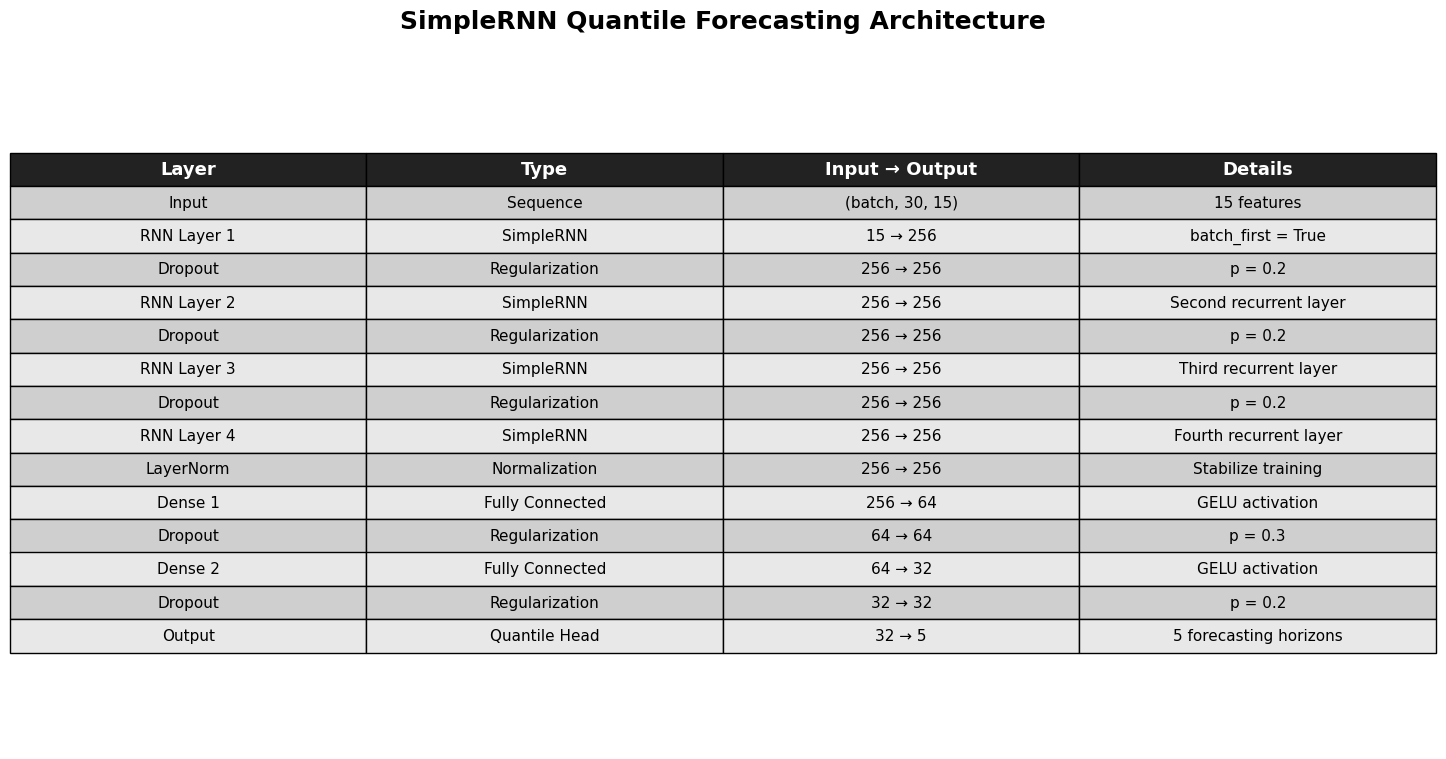

Saved → rnn_architecture_table.png


In [2]:
import matplotlib.pyplot as plt

# =========================
# ARCHITECTURE TABLE DATA
# =========================

architecture_data = [
    ["Input",      "Sequence",      "(batch, 30, 15)", "15 features"],
    ["RNN Layer 1","SimpleRNN",     "15 → 256",        "batch_first = True"],
    ["Dropout",    "Regularization","256 → 256",       "p = 0.2"],
    ["RNN Layer 2","SimpleRNN",     "256 → 256",       "Second recurrent layer"],
    ["Dropout",    "Regularization","256 → 256",       "p = 0.2"],
    ["RNN Layer 3","SimpleRNN",     "256 → 256",       "Third recurrent layer"],
    ["Dropout",    "Regularization","256 → 256",       "p = 0.2"],
    ["RNN Layer 4","SimpleRNN",     "256 → 256",       "Fourth recurrent layer"],
    ["LayerNorm",  "Normalization", "256 → 256",       "Stabilize training"],
    ["Dense 1",    "Fully Connected","256 → 64",       "GELU activation"],
    ["Dropout",    "Regularization","64 → 64",         "p = 0.3"],
    ["Dense 2",    "Fully Connected","64 → 32",        "GELU activation"],
    ["Dropout",    "Regularization","32 → 32",         "p = 0.2"],
    ["Output",     "Quantile Head", "32 → 5",          "5 forecasting horizons"],
]

columns = [
    "Layer",
    "Type",
    "Input → Output",
    "Details"
]

# =========================
# CREATE FIGURE
# =========================

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')

# =========================
# CREATE TABLE
# =========================

tbl = ax.table(
    cellText=architecture_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# =========================
# TABLE STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.15, 2)

# Header styling
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#222222")
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=13
    )

# Body styling
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#e8e8e8")
    else:
        cell.set_facecolor("#cfcfcf")

# =========================
# TITLE
# =========================

plt.title(
    "SimpleRNN Quantile Forecasting Architecture",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# =========================
# SAVE IMAGE
# =========================

plt.savefig(
    "rnn_architecture_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_architecture_table.png")

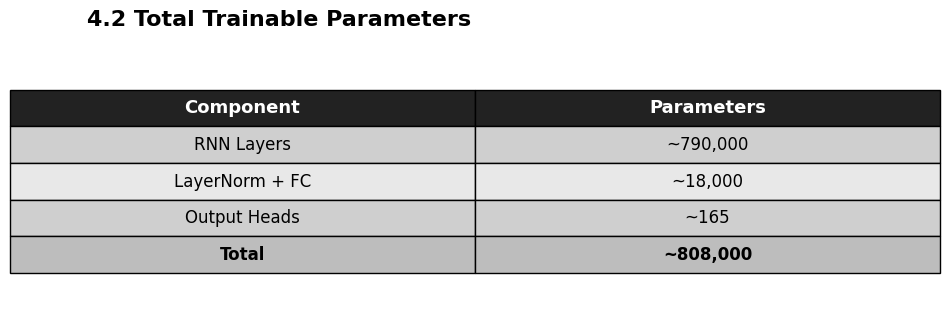

Saved → rnn_parameter_table.png


In [3]:
import matplotlib.pyplot as plt

# =========================
# PARAMETER TABLE DATA
# =========================

parameter_data = [
    ["RNN Layers",     "~790,000"],
    ["LayerNorm + FC", "~18,000"],
    ["Output Heads",   "~165"],
    ["Total",          "~808,000"]
]

columns = [
    "Component",
    "Parameters"
]

# =========================
# CREATE FIGURE
# =========================

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

# =========================
# CREATE TABLE
# =========================

tbl = ax.table(
    cellText=parameter_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 2.2)

# Header styling
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#222222")
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=13
    )

# Body styling
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#e8e8e8")
    else:
        cell.set_facecolor("#cfcfcf")

# Highlight Total row
for col in range(len(columns)):
    tbl[(4, col)].set_facecolor("#bdbdbd")
    tbl[(4, col)].set_text_props(weight='bold')

# =========================
# TITLE
# =========================

plt.title(
    "4.2 Total Trainable Parameters",
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=15
)

# =========================
# SAVE IMAGE
# =========================

plt.savefig(
    "rnn_parameter_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_parameter_table.png")

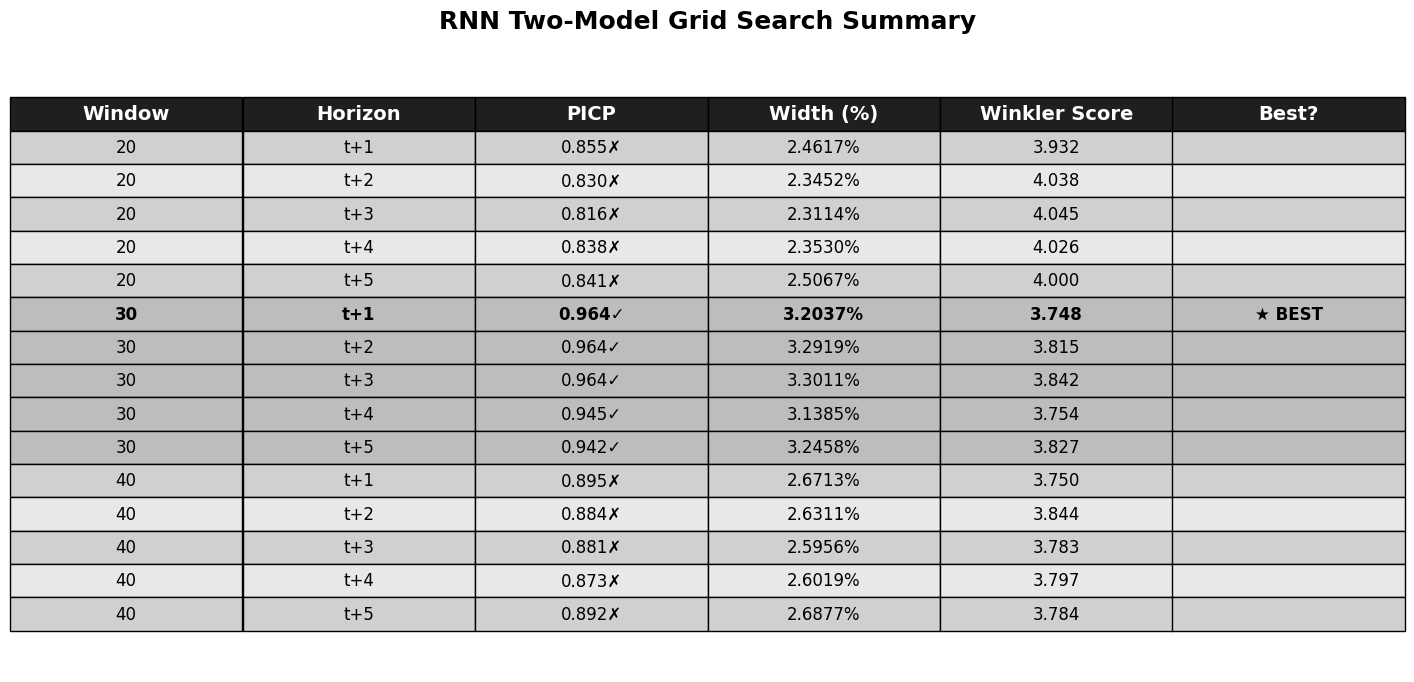

Saved → rnn_grid_search_summary.png


In [4]:
import matplotlib.pyplot as plt

# =========================
# TABLE DATA
# =========================

table_data = [
    ["20", "t+1", "0.855✗", "2.4617%", "3.932", ""],
    ["20", "t+2", "0.830✗", "2.3452%", "4.038", ""],
    ["20", "t+3", "0.816✗", "2.3114%", "4.045", ""],
    ["20", "t+4", "0.838✗", "2.3530%", "4.026", ""],
    ["20", "t+5", "0.841✗", "2.5067%", "4.000", ""],

    ["30", "t+1", "0.964✓", "3.2037%", "3.748", "★ BEST"],
    ["30", "t+2", "0.964✓", "3.2919%", "3.815", ""],
    ["30", "t+3", "0.964✓", "3.3011%", "3.842", ""],
    ["30", "t+4", "0.945✓", "3.1385%", "3.754", ""],
    ["30", "t+5", "0.942✓", "3.2458%", "3.827", ""],

    ["40", "t+1", "0.895✗", "2.6713%", "3.750", ""],
    ["40", "t+2", "0.884✗", "2.6311%", "3.844", ""],
    ["40", "t+3", "0.881✗", "2.5956%", "3.783", ""],
    ["40", "t+4", "0.873✗", "2.6019%", "3.797", ""],
    ["40", "t+5", "0.892✗", "2.6877%", "3.784", ""],
]

columns = [
    "Window",
    "Horizon",
    "PICP",
    "Width (%)",
    "Winkler Score",
    "Best?"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(15, 8))
ax.axis('off')

# =========================
# CREATE TABLE
# =========================

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 2)

# Header style
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=14
    )

# Body style
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # Alternate colors
    if row % 2 == 0:
        cell.set_facecolor("#e8e8e8")
    else:
        cell.set_facecolor("#d0d0d0")

    # Highlight BEST rows
    if 6 <= row <= 10:
        cell.set_facecolor("#bdbdbd")

# Bold BEST row
for col in range(len(columns)):
    tbl[(6, col)].set_text_props(weight='bold')

# =========================
# TITLE
# =========================

plt.title(
    "RNN Two-Model Grid Search Summary",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# =========================
# SAVE IMAGE
# =========================

plt.savefig(
    "rnn_grid_search_summary.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_grid_search_summary.png")

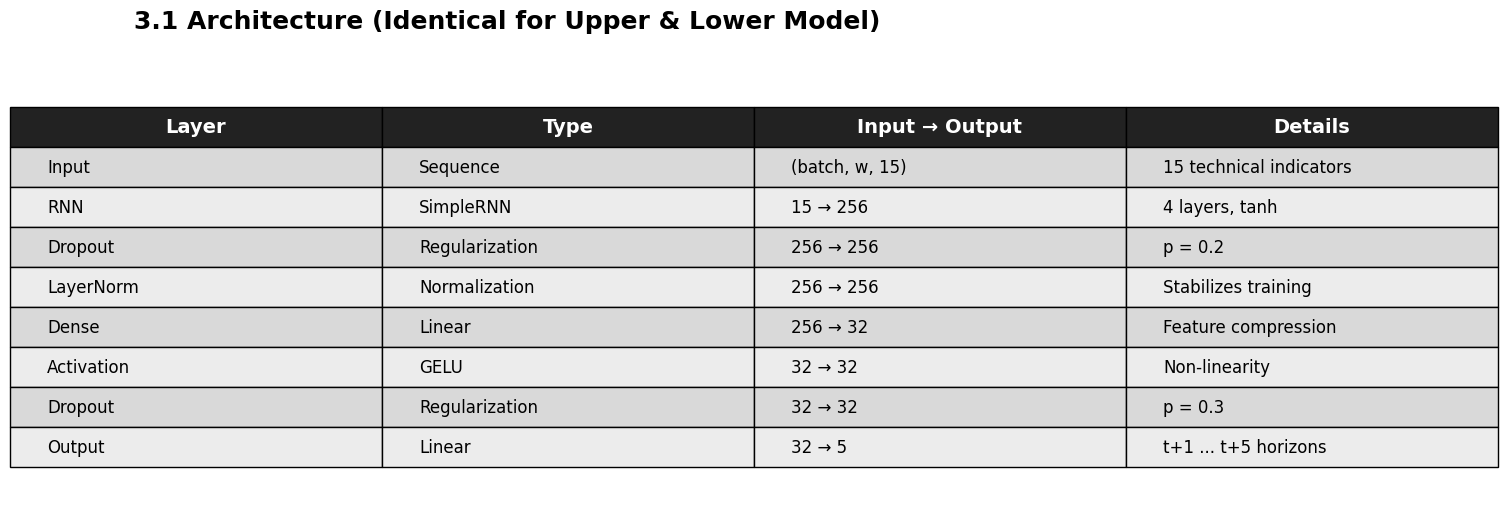

Saved → rnn_architecture_table.png


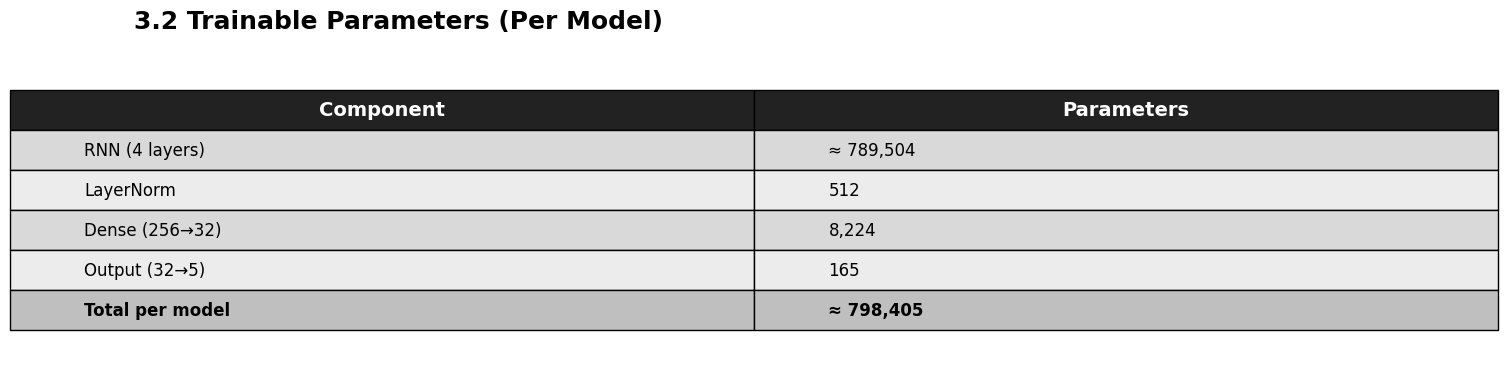

Saved → rnn_parameter_table.png


In [6]:
import matplotlib.pyplot as plt

# =========================
# ARCHITECTURE TABLE DATA
# =========================

architecture_data = [
    ["Input",      "Sequence",      "(batch, w, 15)", "15 technical indicators"],
    ["RNN",        "SimpleRNN",     "15 → 256",       "4 layers, tanh"],
    ["Dropout",    "Regularization","256 → 256",      "p = 0.2"],
    ["LayerNorm",  "Normalization", "256 → 256",      "Stabilizes training"],
    ["Dense",      "Linear",        "256 → 32",       "Feature compression"],
    ["Activation", "GELU",          "32 → 32",        "Non-linearity"],
    ["Dropout",    "Regularization","32 → 32",        "p = 0.3"],
    ["Output",     "Linear",        "32 → 5",         "t+1 ... t+5 horizons"],
]

columns = [
    "Layer",
    "Type",
    "Input → Output",
    "Details"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=architecture_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.2, 2.4)

# Header styling
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#222222")
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=14
    )

# Body styling
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d9d9d9")

# =========================
# TITLE
# =========================

plt.title(
    "3.1 Architecture (Identical for Upper & Lower Model)",
    fontsize=18,
    fontweight='bold',
    loc='left',
    pad=20
)

# =========================
# SAVE
# =========================

plt.savefig(
    "rnn_architecture_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_architecture_table.png")


# =========================================================
# 3.2 TRAINABLE PARAMETERS TABLE
# =========================================================

parameter_data = [
    ["RNN (4 layers)", "≈ 789,504"],
    ["LayerNorm", "512"],
    ["Dense (256→32)", "8,224"],
    ["Output (32→5)", "165"],
    ["Total per model", "≈ 798,405"]
]

columns2 = [
    "Component",
    "Parameters"
]

fig2, ax2 = plt.subplots(figsize=(16, 4))
ax2.axis('off')

tbl2 = ax2.table(
    cellText=parameter_data,
    colLabels=columns2,
    cellLoc='left',
    loc='center'
)

tbl2.auto_set_font_size(False)
tbl2.set_fontsize(12)
tbl2.scale(1.2, 2.4)

# Header styling
for col in range(len(columns2)):
    cell = tbl2[(0, col)]

    cell.set_facecolor("#222222")
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=14
    )

# Body styling
for (row, col), cell in tbl2.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d9d9d9")

# Highlight total row
for col in range(len(columns2)):
    tbl2[(5, col)].set_facecolor("#bfbfbf")
    tbl2[(5, col)].set_text_props(weight='bold')

# Title
plt.title(
    "3.2 Trainable Parameters (Per Model)",
    fontsize=18,
    fontweight='bold',
    loc='left',
    pad=20
)

# Save
plt.savefig(
    "rnn_parameter_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_parameter_table.png")

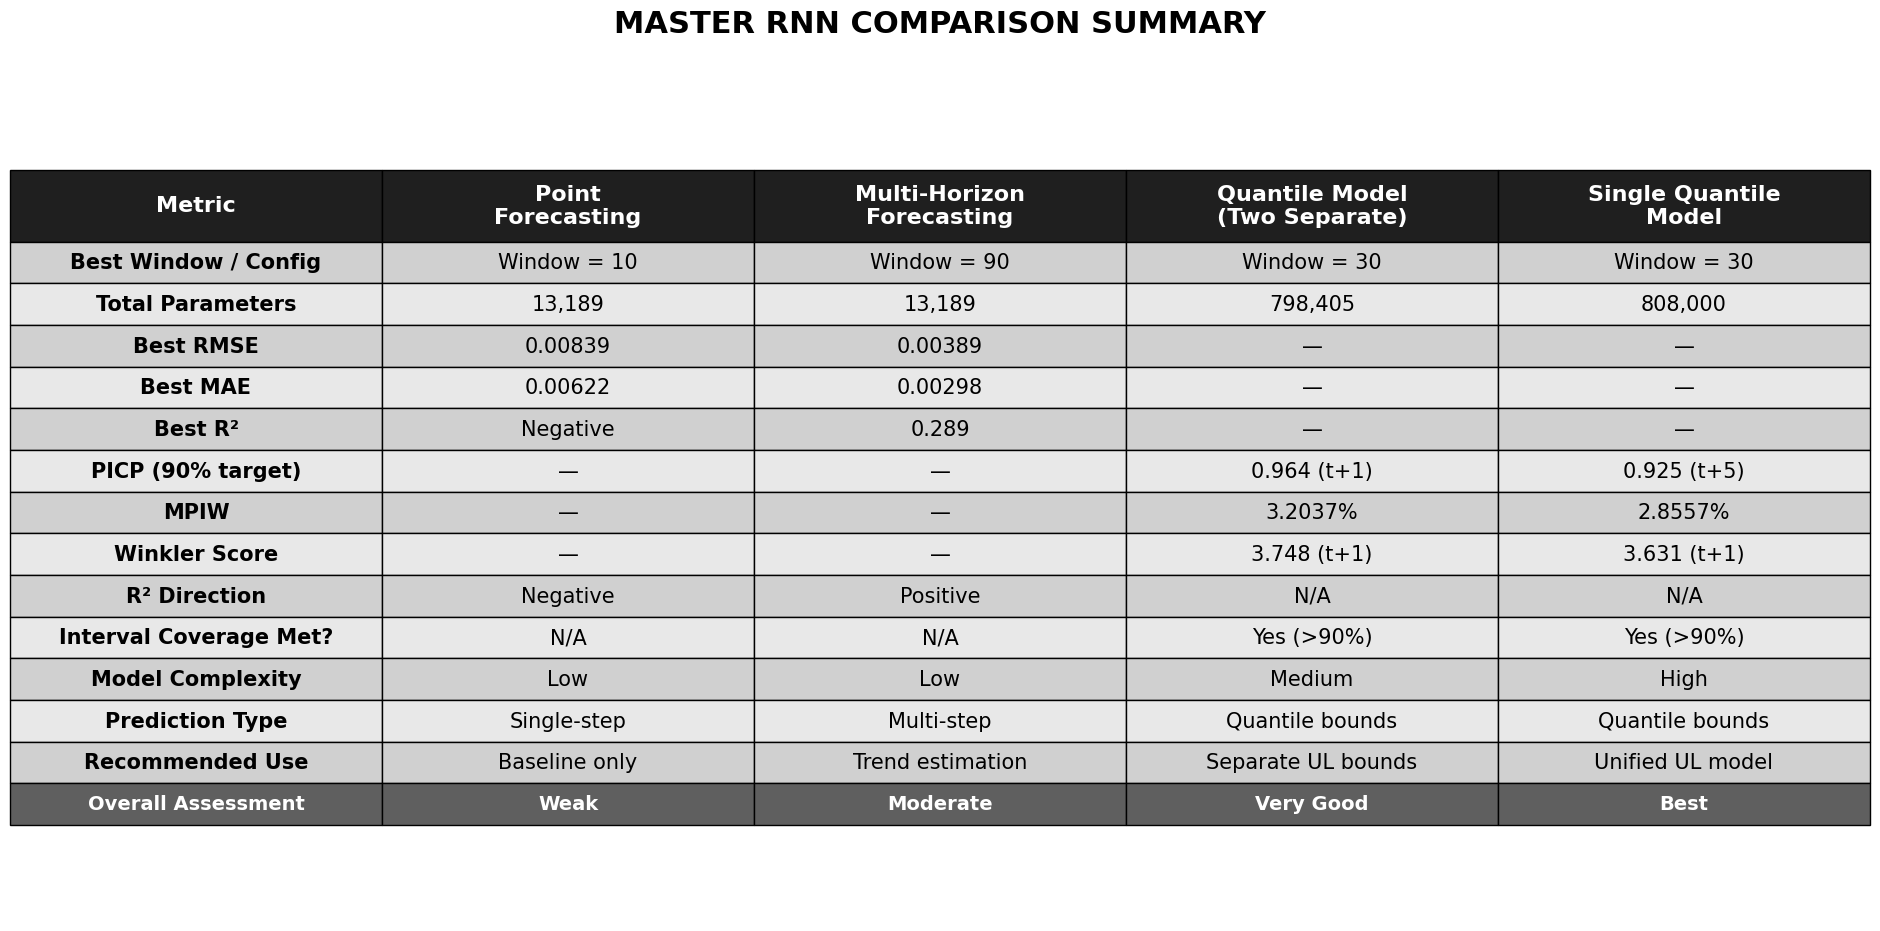

Saved → master_rnn_comparison_summary_updated.png


In [11]:
import matplotlib.pyplot as plt

# =========================
# UPDATED MASTER COMPARISON
# =========================

table_data = [
    ["Best Window / Config", "Window = 10", "Window = 90", "Window = 30", "Window = 30"],
    
    ["Total Parameters", "13,189", "13,189", "798,405", "808,000"],
    
    ["Best RMSE", "0.00839", "0.00389", "—", "—"],
    
    ["Best MAE", "0.00622", "0.00298", "—", "—"],
    
    ["Best R²", "Negative", "0.289", "—", "—"],
    
    ["PICP (90% target)", "—", "—", "0.964 (t+1)", "0.925 (t+5)"],
    
    ["MPIW", "—", "—", "3.2037%", "2.8557%"],
    
    ["Winkler Score", "—", "—", "3.748 (t+1)", "3.631 (t+1)"],
    
    ["R² Direction", "Negative", "Positive", "N/A", "N/A"],
    
    ["Interval Coverage Met?", "N/A", "N/A", "Yes (>90%)", "Yes (>90%)"],
    
    ["Model Complexity", "Low", "Low", "Medium", "High"],
    
    ["Prediction Type", "Single-step", "Multi-step", "Quantile bounds", "Quantile bounds"],
    
    ["Recommended Use", "Baseline only", "Trend estimation", "Separate UL bounds", "Unified UL model"],
    
    ["Overall Assessment", "Weak", "Moderate", "Very Good", "Best"]
]

columns = [
    "Metric",
    "Point\nForecasting",
    "Multi-Horizon\nForecasting",
    "Quantile Model\n(Two Separate)",
    "Single Quantile\nModel"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(20, 11))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(15)

# Increase overall table size
tbl.scale(1.2, 2.5)

# =========================
# HEADER STYLING
# =========================

for col in range(len(columns)):
    
    cell = tbl[(0, col)]

    # Dark header
    cell.set_facecolor("#1f1f1f")

    # Bigger header font
    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    # Increase header box height
    cell.set_height(0.085)

# =========================
# BODY STYLING
# =========================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # Alternate row colors
    if row % 2 == 0:
        cell.set_facecolor("#e8e8e8")
    else:
        cell.set_facecolor("#d0d0d0")

    # Bold first column
    if col == 0:
        cell.set_text_props(weight='bold')

# =========================
# HIGHLIGHT FINAL ROW
# =========================

last_row = len(table_data)

for col in range(len(columns)):
    
    tbl[(last_row, col)].set_facecolor("#5f5f5f")
    
    tbl[(last_row, col)].set_text_props(
        color='white',
        weight='bold',
        fontsize=14
    )

# =========================
# TITLE
# =========================

plt.title(
    "MASTER RNN COMPARISON SUMMARY",
    fontsize=22,
    fontweight='bold',
    pad=30
)

# =========================
# SAVE
# =========================

plt.savefig(
    "master_rnn_comparison_summary_updated.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → master_rnn_comparison_summary_updated.png")

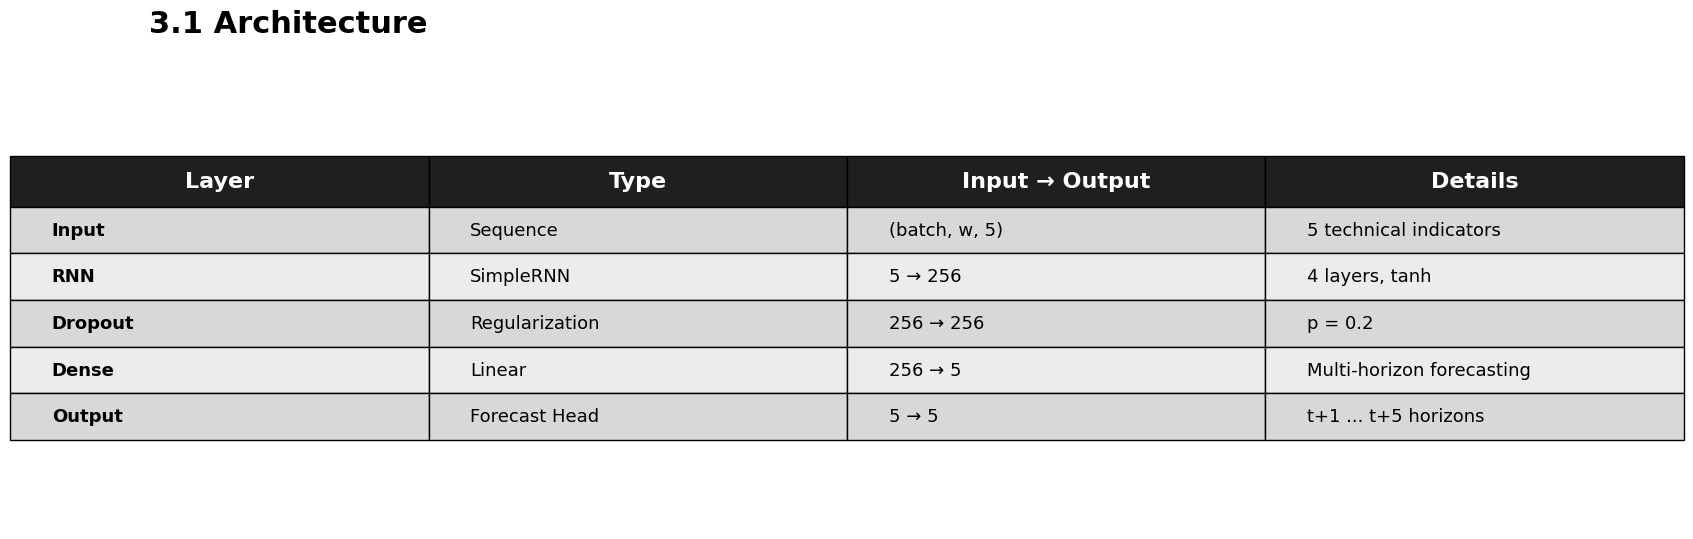

Saved → architecture_table.png


In [12]:
import matplotlib.pyplot as plt

# =========================
# ARCHITECTURE TABLE DATA
# =========================

architecture_data = [
    ["Input",      "Sequence",      "(batch, w, 5)", "5 technical indicators"],
    
    ["RNN",        "SimpleRNN",     "5 → 256",       "4 layers, tanh"],
    
    ["Dropout",    "Regularization","256 → 256",     "p = 0.2"],
    
    ["Dense",      "Linear",        "256 → 5",       "Multi-horizon forecasting"],
    
    ["Output",     "Forecast Head", "5 → 5",         "t+1 ... t+5 horizons"],
]

columns = [
    "Layer",
    "Type",
    "Input → Output",
    "Details"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=architecture_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)

# Bigger table scaling
tbl.scale(1.2, 2.8)

# =========================
# HEADER STYLE
# =========================

for col in range(len(columns)):
    
    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    # Increase black box/header height
    cell.set_height(0.11)

# =========================
# BODY STYLE
# =========================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # Alternate row colors
    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

    # Bold first column
    if col == 0:
        cell.set_text_props(weight='bold')

# =========================
# TITLE
# =========================

plt.title(
    "3.1 Architecture",
    fontsize=22,
    fontweight='bold',
    loc='left',
    pad=25
)

# =========================
# SAVE
# =========================

plt.savefig(
    "architecture_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → architecture_table.png")

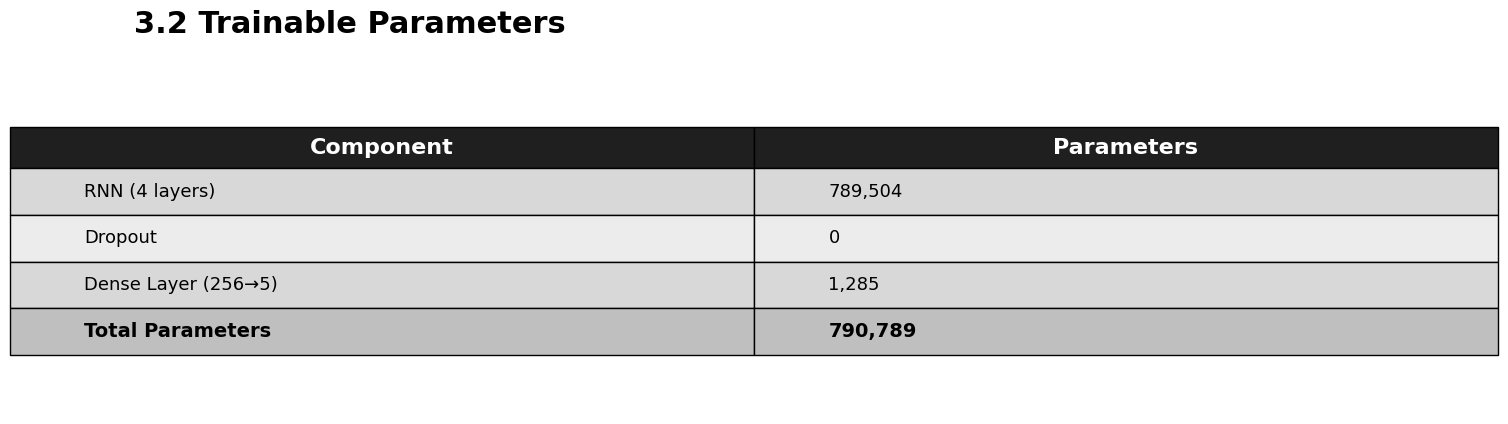

Saved → trainable_parameters_table.png


In [13]:
import matplotlib.pyplot as plt

# =========================
# TRAINABLE PARAMETER DATA
# =========================

parameter_data = [
    ["RNN (4 layers)", "789,504"],
    
    ["Dropout", "0"],
    
    ["Dense Layer (256→5)", "1,285"],
    
    ["Total Parameters", "790,789"]
]

columns = [
    "Component",
    "Parameters"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=parameter_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)

# Bigger table
tbl.scale(1.2, 2.8)

# =========================
# HEADER STYLE
# =========================

for col in range(len(columns)):

    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    # Bigger black header box
    cell.set_height(0.12)

# =========================
# BODY STYLE
# =========================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    # Alternate row colors
    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

# =========================
# HIGHLIGHT TOTAL ROW
# =========================

last_row = len(parameter_data)

for col in range(len(columns)):

    tbl[(last_row, col)].set_facecolor("#bfbfbf")

    tbl[(last_row, col)].set_text_props(
        weight='bold',
        fontsize=14
    )

# =========================
# TITLE
# =========================

plt.title(
    "3.2 Trainable Parameters",
    fontsize=22,
    fontweight='bold',
    loc='left',
    pad=25
)

# =========================
# SAVE
# =========================

plt.savefig(
    "trainable_parameters_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → trainable_parameters_table.png")

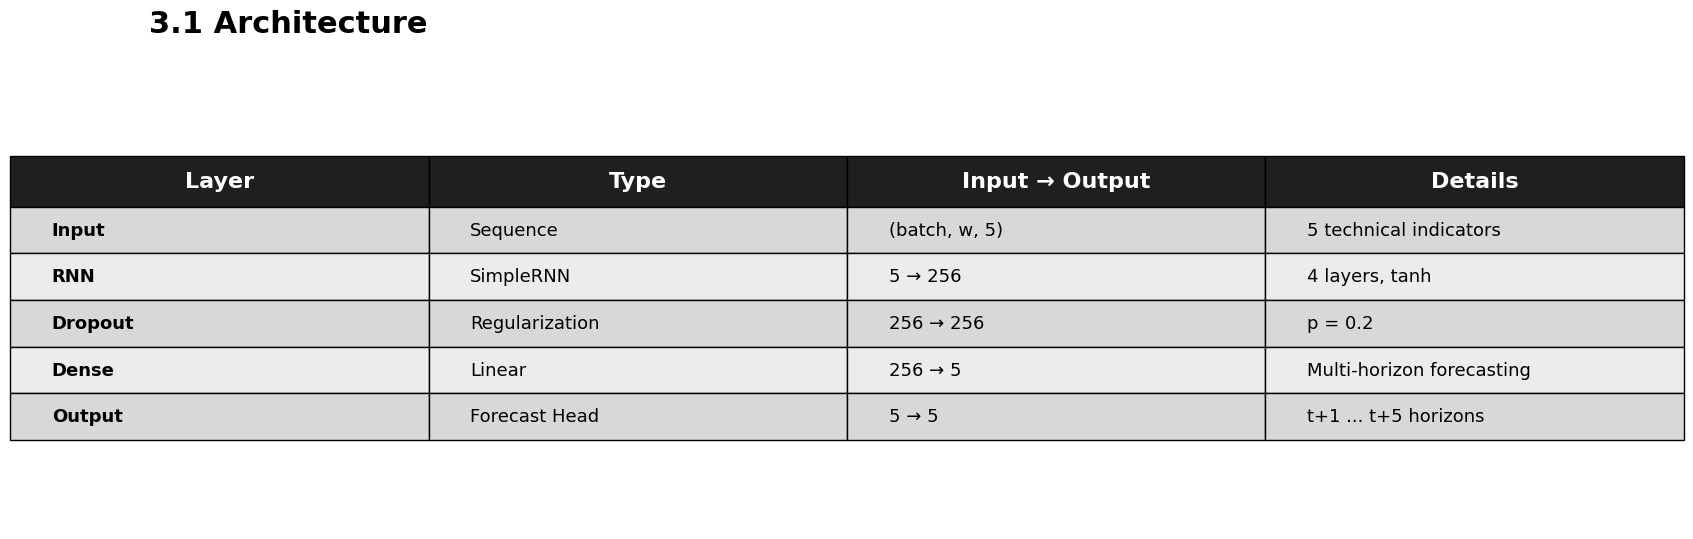

Saved → architecture_table.png


In [15]:
import matplotlib.pyplot as plt

# =========================
# ARCHITECTURE TABLE DATA
# =========================

architecture_data = [
    ["Input",      "Sequence",      "(batch, w, 5)", "5 technical indicators"],
    
    ["RNN",        "SimpleRNN",     "5 → 256",       "4 layers, tanh"],
    
    ["Dropout",    "Regularization","256 → 256",     "p = 0.2"],
    
    ["Dense",      "Linear",        "256 → 5",       "Multi-horizon forecasting"],
    
    ["Output",     "Forecast Head", "5 → 5",         "t+1 ... t+5 horizons"],
]

columns = [
    "Layer",
    "Type",
    "Input → Output",
    "Details"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=architecture_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)

tbl.scale(1.2, 2.8)

# =========================
# HEADER STYLE
# =========================

for col in range(len(columns)):

    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    cell.set_height(0.11)

# =========================
# BODY STYLE
# =========================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

    if col == 0:
        cell.set_text_props(weight='bold')

# =========================
# TITLE
# =========================

plt.title(
    "3.1 Architecture",
    fontsize=22,
    fontweight='bold',
    loc='left',
    pad=25
)

# =========================
# SAVE
# =========================

plt.savefig(
    "architecture_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → architecture_table.png")

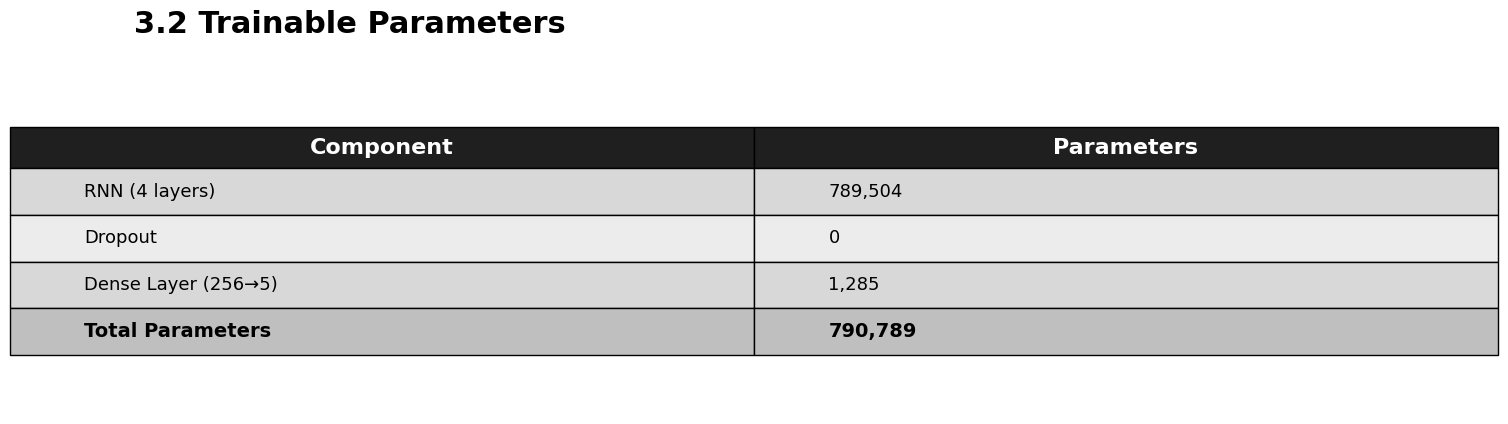

Saved → trainable_parameters_table.png


In [16]:
import matplotlib.pyplot as plt

# =========================
# TRAINABLE PARAMETER DATA
# =========================

parameter_data = [
    ["RNN (4 layers)", "789,504"],
    
    ["Dropout", "0"],
    
    ["Dense Layer (256→5)", "1,285"],
    
    ["Total Parameters", "790,789"]
]

columns = [
    "Component",
    "Parameters"
]

# =========================
# FIGURE
# =========================

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis('off')

# =========================
# TABLE
# =========================

tbl = ax.table(
    cellText=parameter_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

# =========================
# STYLE
# =========================

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)

tbl.scale(1.2, 2.8)

# =========================
# HEADER STYLE
# =========================

for col in range(len(columns)):

    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    cell.set_height(0.12)

# =========================
# BODY STYLE
# =========================

for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

# =========================
# HIGHLIGHT TOTAL ROW
# =========================

last_row = len(parameter_data)

for col in range(len(columns)):

    tbl[(last_row, col)].set_facecolor("#bfbfbf")

    tbl[(last_row, col)].set_text_props(
        weight='bold',
        fontsize=14
    )

# =========================
# TITLE
# =========================

plt.title(
    "3.2 Trainable Parameters",
    fontsize=22,
    fontweight='bold',
    loc='left',
    pad=25
)

# =========================
# SAVE
# =========================

plt.savefig(
    "trainable_parameters_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → trainable_parameters_table.png")

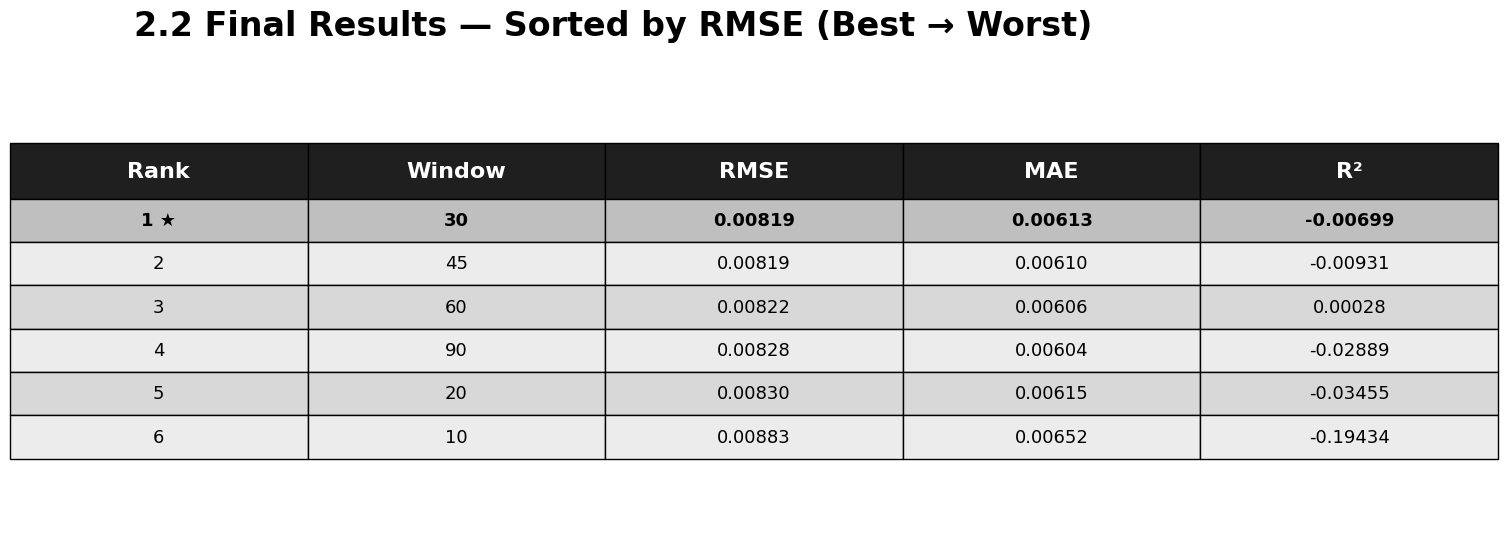

Saved → rnn_nextday_results_table.png


In [17]:
# =========================================================
# TABLE 1 : RNN NEXT-DAY FORECASTING RESULTS
# =========================================================

import matplotlib.pyplot as plt

table_data = [
    ["1 ★", "30", "0.00819", "0.00613", "-0.00699"],
    ["2",   "45", "0.00819", "0.00610", "-0.00931"],
    ["3",   "60", "0.00822", "0.00606", "0.00028"],
    ["4",   "90", "0.00828", "0.00604", "-0.02889"],
    ["5",   "20", "0.00830", "0.00615", "-0.03455"],
    ["6",   "10", "0.00883", "0.00652", "-0.19434"],
]

columns = ["Rank", "Window", "RMSE", "MAE", "R²"]

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.2, 2.6)

# Header styling
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    cell.set_height(0.12)

# Body styling
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

# Highlight BEST row
for col in range(len(columns)):
    tbl[(1, col)].set_facecolor("#bfbfbf")
    tbl[(1, col)].set_text_props(weight='bold')

plt.title(
    "2.2 Final Results — Sorted by RMSE (Best → Worst)",
    fontsize=24,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.savefig(
    "rnn_nextday_results_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_nextday_results_table.png")

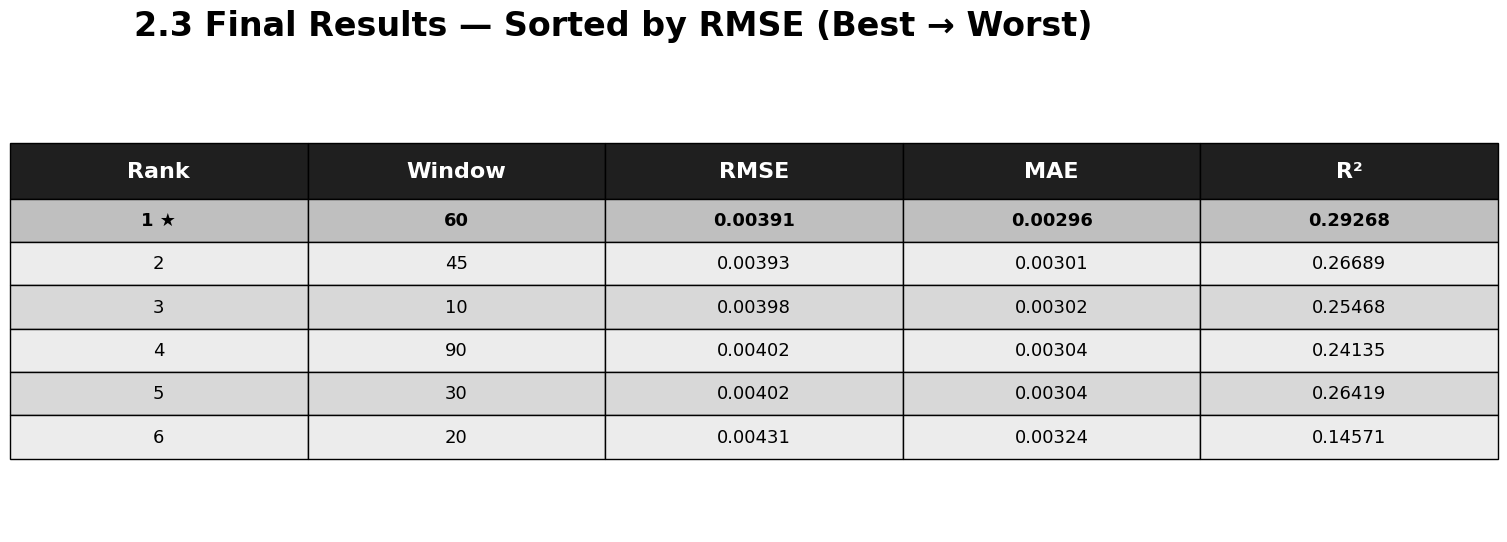

Saved → rnn_multihorizon_results_table.png


In [18]:
# =========================================================
# TABLE 2 : RNN MULTI-HORIZON FORECASTING RESULTS
# =========================================================

import matplotlib.pyplot as plt

table_data = [
    ["1 ★", "60", "0.00391", "0.00296", "0.29268"],
    ["2",   "45", "0.00393", "0.00301", "0.26689"],
    ["3",   "10", "0.00398", "0.00302", "0.25468"],
    ["4",   "90", "0.00402", "0.00304", "0.24135"],
    ["5",   "30", "0.00402", "0.00304", "0.26419"],
    ["6",   "20", "0.00431", "0.00324", "0.14571"],
]

columns = ["Rank", "Window", "RMSE", "MAE", "R²"]

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.2, 2.6)

# Header styling
for col in range(len(columns)):
    cell = tbl[(0, col)]

    cell.set_facecolor("#1f1f1f")

    cell.set_text_props(
        color='white',
        weight='bold',
        fontsize=16
    )

    cell.set_height(0.12)

# Body styling
for (row, col), cell in tbl.get_celld().items():

    if row == 0:
        continue

    if row % 2 == 0:
        cell.set_facecolor("#ececec")
    else:
        cell.set_facecolor("#d8d8d8")

# Highlight BEST row
for col in range(len(columns)):
    tbl[(1, col)].set_facecolor("#bfbfbf")
    tbl[(1, col)].set_text_props(weight='bold')

plt.title(
    "2.3 Final Results — Sorted by RMSE (Best → Worst)",
    fontsize=24,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.savefig(
    "rnn_multihorizon_results_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → rnn_multihorizon_results_table.png")

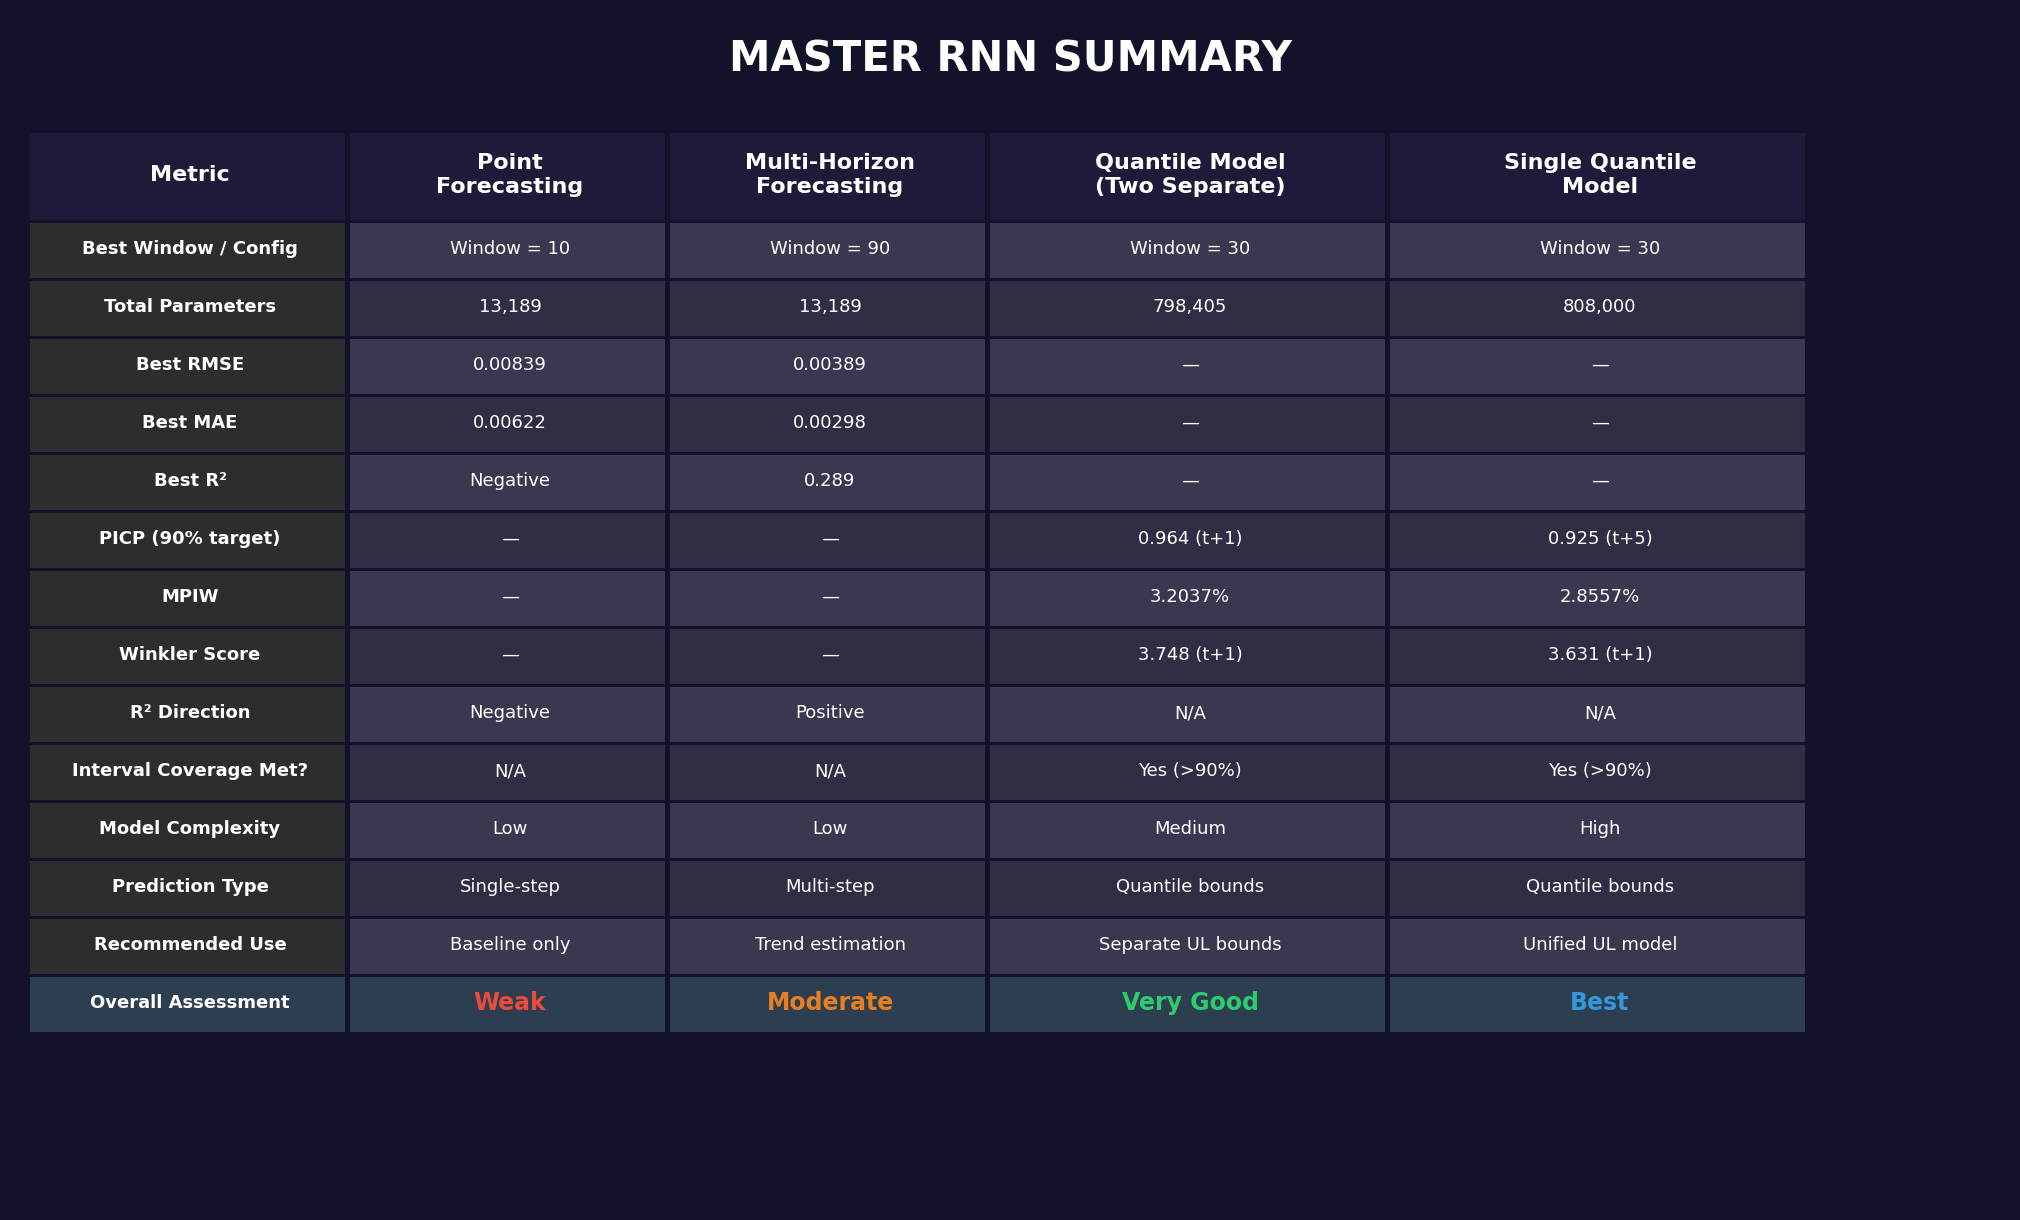

Saved → rnn_master_summary.png


In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

ROWS = [
    ("Best Window / Config",   ["Window = 10",    "Window = 90",      "Window = 30",       "Window = 30"]),
    ("Total Parameters",       ["13,189",          "13,189",           "798,405",           "808,000"]),
    ("Best RMSE",              ["0.00839",         "0.00389",          "—",                 "—"]),
    ("Best MAE",               ["0.00622",         "0.00298",          "—",                 "—"]),
    ("Best R²",                ["Negative",        "0.289",            "—",                 "—"]),
    ("PICP (90% target)",      ["—",               "—",                "0.964 (t+1)",       "0.925 (t+5)"]),
    ("MPIW",                   ["—",               "—",                "3.2037%",           "2.8557%"]),
    ("Winkler Score",          ["—",               "—",                "3.748 (t+1)",       "3.631 (t+1)"]),
    ("R² Direction",           ["Negative",        "Positive",         "N/A",               "N/A"]),
    ("Interval Coverage Met?", ["N/A",             "N/A",              "Yes (>90%)",        "Yes (>90%)"]),
    ("Model Complexity",       ["Low",             "Low",              "Medium",            "High"]),
    ("Prediction Type",        ["Single-step",     "Multi-step",       "Quantile bounds",   "Quantile bounds"]),
    ("Recommended Use",        ["Baseline only",   "Trend estimation", "Separate UL bounds","Unified UL model"]),
    ("Overall Assessment",     ["Weak",            "Moderate",         "Very Good",         "Best"]),
]

COLS = ["Point\nForecasting", "Multi-Horizon\nForecasting", "Quantile Model\n(Two Separate)", "Single Quantile\nModel"]
ASSESS_CLR = {"Weak": "#e74c3c", "Moderate": "#e67e22", "Very Good": "#2ecc71", "Best": "#3498db"}

fig, ax = plt.subplots(figsize=(20, 12))
ax.set_xlim(0, 20); ax.set_ylim(0, 12); ax.axis("off")
fig.patch.set_facecolor("#12122a")

# Title
ax.text(10, 11.5, "MASTER RNN SUMMARY", ha="center", va="center",
        fontsize=30, fontweight="bold", color="white")

# Layout
CW = [3.2, 3.2, 3.2, 4.0, 4.2]
X  = [0.2]
for w in CW[:-1]: X.append(X[-1] + w)
RH, TOP, HH = 0.58, 10.8, 0.90

# Header
for label, x, w in zip(["Metric"] + COLS, X, CW):
    ax.add_patch(FancyBboxPatch((x, TOP - HH), w-0.05, HH-0.03,
                                boxstyle="square,pad=0", facecolor="#1c1c3a", linewidth=0))
    ax.text(x + w/2, TOP - HH/2, label, ha="center", va="center",
            fontsize=16, fontweight="bold", color="white", multialignment="center")

# Rows
for ri, (metric, vals) in enumerate(ROWS):
    ry = TOP - HH - (ri + 1) * RH
    last = ri == len(ROWS) - 1
    for ci, (cell, x, w) in enumerate(zip([metric] + vals, X, CW)):
        bg = "#2c3e50" if last else ("#2d2d2d" if ci == 0 else ("#383850" if ri%2==0 else "#2e2e44"))
        ax.add_patch(FancyBboxPatch((x, ry), w-0.05, RH-0.03,
                                    boxstyle="square,pad=0", facecolor=bg, linewidth=0))
        fc = ASSESS_CLR.get(cell, "white") if last and ci > 0 else "white"
        fw = "bold" if ci == 0 or last else "normal"
        fs = 17 if last and ci > 0 else 13
        ax.text(x + w/2, ry + RH/2, cell, ha="center", va="center",
                fontsize=fs, fontweight=fw, color=fc)

plt.tight_layout(pad=0)
plt.savefig("rnn_master_summary.png", dpi=180, bbox_inches="tight", facecolor="#12122a")
plt.show()
print("Saved → rnn_master_summary.png")